# Samurai Benchmark Visualization

This notebook combines the functionality of `plot_bench.py` and `plot_worker_latency.py` to provide a comprehensive view of benchmark results.


In [1]:
import glob
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Configure matplotlib styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

## Configuration

Set the parameters for the analysis below. You can change the file patterns to match your specific benchmark run.

In [2]:
# Configuration
UPDATES_CSV_PATTERN = "../../benchmark_output/bench_updates_20260119_130304.csv"
BLOCKS_CSV_PATTERN = "../../benchmark_output/bench_blocks_20260119_130304.csv"
# UPDATES_CSV_PATTERN = "/data/local/samurai/test/benchmark/bench_updates_20260114_181151.csv"
# BLOCKS_CSV_PATTERN = "/data/local/samurai/test/benchmark/bench_blocks_20260114_181151.csv"

WINDOW_S = 5.0      # Aggregation window in seconds
WARMUP_S = 30.0     # Warmup period to trim in seconds
COOLDOWN_S = 30.0   # Cooldown period to trim in seconds

# Search directory (default to current directory)
SEARCH_DIR = "."

## Helper Functions

These functions handle data loading, processing, and plotting.

In [3]:
def load_updates_csv(filepath: str) -> pd.DataFrame:
    """Load updates CSV file."""
    print(f"Loading updates from {filepath}...")
    df = pd.read_csv(filepath)
    # Convert nanoseconds to seconds for time-based grouping
    df["completed_at_s"] = df["completed_at_ns"] / 1e9
    # Convert latency to milliseconds for readability
    df["latency_ms"] = df["latency_ns"] / 1e6
    return df


def load_blocks_csv(filepath: str) -> pd.DataFrame:
    """Load blocks CSV file."""
    print(f"Loading blocks from {filepath}...")
    df = pd.read_csv(filepath)
    # Convert nanoseconds to seconds
    df["submitted_at_s"] = df["submitted_at_ns"] / 1e9
    df["completed_at_s"] = df["completed_at_ns"] / 1e9
    # Calculate latency in milliseconds
    df["latency_ms"] = (df["completed_at_ns"] - df["submitted_at_ns"]) / 1e6
    return df


def trim_warmup_cooldown(
    df: pd.DataFrame, time_col: str, warmup_s: float, cooldown_s: float
) -> pd.DataFrame:
    """Trim warmup and cooldown periods from the data."""
    if df.empty:
        return df

    min_time = df[time_col].min()
    max_time = df[time_col].max()

    start_time = min_time + warmup_s
    end_time = max_time - cooldown_s

    if start_time >= end_time:
        print(
            f"Warning: warmup ({warmup_s}s) + cooldown ({cooldown_s}s) >= total duration. No data left."
        )
        return df.iloc[0:0]  # Return empty dataframe with same columns

    trimmed = df[(df[time_col] >= start_time) & (df[time_col] <= end_time)].copy()
    # Normalize time to start from 0
    trimmed["time_normalized"] = trimmed[time_col] - start_time
    return trimmed


def aggregate_by_window(
    df: pd.DataFrame, time_col: str, window_s: float, value_col: str, agg_func: str
) -> pd.DataFrame:
    """Aggregate data by time window."""
    if df.empty:
        return pd.DataFrame(columns=["window_start", "value"])

    # Create window bins
    df = df.copy()
    df["window"] = (df[time_col] // window_s).astype(int)

    if agg_func == "mean":
        result = df.groupby("window")[value_col].mean().reset_index()
    elif agg_func == "count":
        result = df.groupby("window").size().reset_index(name="value")
        result["value"] = result["value"] / window_s  # Convert to per-second rate
    else:
        raise ValueError(f"Unknown aggregation function: {agg_func}")

    result["window_start"] = result["window"] * window_s
    if agg_func == "mean":
        result = result.rename(columns={value_col: "value"})

    return result[["window_start", "value"]]


def aggregate_latency_by_window(
    df: pd.DataFrame, time_col: str, window_s: float
) -> pd.DataFrame:
    """Aggregate latency by time window."""
    if df.empty:
        return pd.DataFrame(columns=["window_start", "mean", "p50", "p95", "p99"])

    df = df.copy()
    df["window"] = (df[time_col] // window_s).astype(int)

    result = df.groupby("window")["latency_ms"].agg(
        mean="mean", p50="median", p95=lambda x: x.quantile(0.95), p99=lambda x: x.quantile(0.99)
    ).reset_index()
    result["window_start"] = result["window"] * window_s

    return result


def aggregate_throughput_by_window(
    df: pd.DataFrame, time_col: str, window_s: float
) -> pd.DataFrame:
    """Aggregate throughput (count per second) by time window."""
    if df.empty:
        return pd.DataFrame(columns=["window_start", "throughput"])

    df = df.copy()
    df["window"] = (df[time_col] // window_s).astype(int)

    result = df.groupby("window").size().reset_index(name="count")
    result["throughput"] = result["count"] / window_s  # Convert to per-second rate
    result["window_start"] = result["window"] * window_s

    return result[["window_start", "throughput"]]

### Plotting Functions

In [4]:
def plot_latency(
    ax: plt.Axes,
    df: pd.DataFrame,
    title: str,
    ylabel: str,
    color: str,
    window_s: float,
):
    """Plot latency over time."""
    if df.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        return

    agg = aggregate_by_window(df, "time_normalized", window_s, "latency_ms", "mean")

    ax.plot(agg["window_start"], agg["value"], color=color, linewidth=1.5)
    ax.fill_between(agg["window_start"], agg["value"], alpha=0.3, color=color)
    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

    # Add statistics annotation
    if not df.empty:
        mean_lat = df["latency_ms"].mean()
        p50 = df["latency_ms"].median()
        p95 = df["latency_ms"].quantile(0.95)
        p99 = df["latency_ms"].quantile(0.99)
        stats_text = f"Mean: {mean_lat:.2f}ms\nP50: {p50:.2f}ms\nP95: {p95:.2f}ms\nP99: {p99:.2f}ms"
        ax.text(
            0.08,
            0.98,
            stats_text,
            transform=ax.transAxes,
            fontsize=9,
            verticalalignment="top",
            horizontalalignment="right",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
        )

def plot_throughput(
    ax: plt.Axes,
    df: pd.DataFrame,
    time_col: str,
    title: str,
    ylabel: str,
    color: str,
    window_s: float,
):
    """Plot throughput over time."""
    if df.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        return

    agg = aggregate_by_window(df, "time_normalized", window_s, None, "count")

    ax.plot(agg["window_start"], agg["value"], color=color, linewidth=1.5)
    ax.fill_between(agg["window_start"], agg["value"], alpha=0.3, color=color)
    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

    # Add statistics annotation
    if not agg.empty:
        avg_throughput = agg["value"].mean()
        max_throughput = agg["value"].max()
        min_throughput = agg["value"].min()
        stats_text = (
            f"Avg: {avg_throughput:.1f}/s\nMax: {max_throughput:.1f}/s\nMin: {min_throughput:.1f}/s"
        )
        ax.text(
            0.98,
            0.98,
            stats_text,
            transform=ax.transAxes,
            fontsize=9,
            verticalalignment="top",
            horizontalalignment="right",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
        )

def plot_worker_latency(
    ax: plt.Axes,
    df: pd.DataFrame,
    worker_id: int,
    color: str,
    window_s: float,
):
    """Plot latency over time for a single worker."""
    if df.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"Worker {worker_id}")
        return

    agg = aggregate_latency_by_window(df, "time_normalized", window_s)

    ax.plot(agg["window_start"], agg["mean"], color=color, linewidth=1.5, label="Mean")
    ax.fill_between(agg["window_start"], agg["mean"], alpha=0.3, color=color)
    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel("Latency (ms)")
    ax.set_title(f"Worker {worker_id}")
    ax.grid(True, alpha=0.3)

    # Add statistics annotation
    mean_lat = df["latency_ms"].mean()
    p50 = df["latency_ms"].median()
    p95 = df["latency_ms"].quantile(0.95)
    p99 = df["latency_ms"].quantile(0.99)
    count = len(df)
    stats_text = f"N: {count:,}\nMean: {mean_lat:.2f}ms\nP50: {p50:.2f}ms\nP95: {p95:.2f}ms\nP99: {p99:.2f}ms"
    ax.text(
        0.98,
        0.98,
        stats_text,
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
    )

def plot_worker_throughput(
    ax: plt.Axes,
    df: pd.DataFrame,
    worker_id: int,
    color: str,
    window_s: float,
):
    """Plot throughput over time for a single worker."""
    if df.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"Worker {worker_id}")
        return

    agg = aggregate_throughput_by_window(df, "time_normalized", window_s)

    ax.plot(agg["window_start"], agg["throughput"], color=color, linewidth=1.5)
    ax.fill_between(agg["window_start"], agg["throughput"], alpha=0.3, color=color)
    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel("Updates/sec")
    ax.set_title(f"Worker {worker_id}")
    ax.grid(True, alpha=0.3)

    # Add statistics annotation
    avg_tp = agg["throughput"].mean()
    max_tp = agg["throughput"].max()
    min_tp = agg["throughput"].min()
    count = len(df)
    stats_text = f"N: {count:,}\nAvg: {avg_tp:.1f}/s\nMax: {max_tp:.1f}/s\nMin: {min_tp:.1f}/s"
    ax.text(
        0.98,
        0.98,
        stats_text,
        transform=ax.transAxes,
        fontsize=8,
        verticalalignment="top",
        horizontalalignment="right",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
    )

def plot_all_workers_latency_overlay(
    ax: plt.Axes,
    df: pd.DataFrame,
    colors: list,
    window_s: float,
):
    """Plot all workers' latency on a single chart."""
    if df.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title("All Workers Latency")
        return

    worker_ids = sorted(df["worker_id"].unique())

    for i, worker_id in enumerate(worker_ids):
        worker_df = df[df["worker_id"] == worker_id]
        agg = aggregate_latency_by_window(worker_df, "time_normalized", window_s)
        color = colors[i % len(colors)]
        ax.plot(
            agg["window_start"],
            agg["mean"],
            color=color,
            linewidth=1.2,
            label=f"Worker {worker_id}",
            alpha=0.8,
        )

    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel("Avg Latency (ms)")
    ax.set_title("All Workers Latency Comparison")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right", fontsize=8, ncol=2)

def plot_all_workers_throughput_overlay(
    ax: plt.Axes,
    df: pd.DataFrame,
    colors: list,
    window_s: float,
):
    """Plot all workers' throughput on a single chart."""
    if df.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title("All Workers Throughput")
        return

    worker_ids = sorted(df["worker_id"].unique())

    for i, worker_id in enumerate(worker_ids):
        worker_df = df[df["worker_id"] == worker_id]
        agg = aggregate_throughput_by_window(worker_df, "time_normalized", window_s)
        color = colors[i % len(colors)]
        ax.plot(
            agg["window_start"],
            agg["throughput"],
            color=color,
            linewidth=1.2,
            label=f"Worker {worker_id}",
            alpha=0.8,
        )

    ax.set_xlabel("Time (seconds)")
    ax.set_ylabel("Updates/sec")
    ax.set_title("All Workers Throughput Comparison")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right", fontsize=8, ncol=2)

## Load Data

Automatically find the most recent matching files in the directory.

In [5]:
# Find files
updates_files = sorted(glob.glob(os.path.join(SEARCH_DIR, UPDATES_CSV_PATTERN)))
blocks_files = sorted(glob.glob(os.path.join(SEARCH_DIR, BLOCKS_CSV_PATTERN)))

if not updates_files:
    print(f"No files found matching {UPDATES_CSV_PATTERN}")
    updates_file = None
else:
    updates_file = updates_files[-1]  # Take the most recent one
    print(f"Found updates file: {updates_file}")

if not blocks_files:
    print(f"No files found matching {BLOCKS_CSV_PATTERN}")
    blocks_file = None
else:
    blocks_file = blocks_files[-1]  # Take the most recent one
    print(f"Found blocks file: {blocks_file}")

Found updates file: ./../../benchmark_output/bench_updates_20260119_130304.csv
Found blocks file: ./../../benchmark_output/bench_blocks_20260119_130304.csv


In [6]:
# Load and trim data
updates_df = pd.DataFrame()
blocks_df = pd.DataFrame()

if updates_file:
    updates_df = load_updates_csv(updates_file)
    print(f"Loaded {len(updates_df)} update records")
    updates_trimmed = trim_warmup_cooldown(updates_df, "completed_at_s", WARMUP_S, COOLDOWN_S)
    print(f"Trimmed updates: {len(updates_trimmed)} records")
else:
    updates_trimmed = pd.DataFrame(columns=["completed_at_s", "latency_ms", "worker_id"])

if blocks_file:
    blocks_df = load_blocks_csv(blocks_file)
    print(f"Loaded {len(blocks_df)} block records")
    blocks_trimmed = trim_warmup_cooldown(blocks_df, "completed_at_s", WARMUP_S, COOLDOWN_S)
    print(f"Trimmed blocks: {len(blocks_trimmed)} records")
else:
    blocks_trimmed = pd.DataFrame(columns=["completed_at_s", "latency_ms"])

Loading updates from ./../../benchmark_output/bench_updates_20260119_130304.csv...
Loaded 47661494 update records
Trimmed updates: 45738498 records
Loading blocks from ./../../benchmark_output/bench_blocks_20260119_130304.csv...
Loaded 130351 block records
Trimmed blocks: 125570 records


## Overall System Performance

Overview of latency and throughput for both updates and block generation.

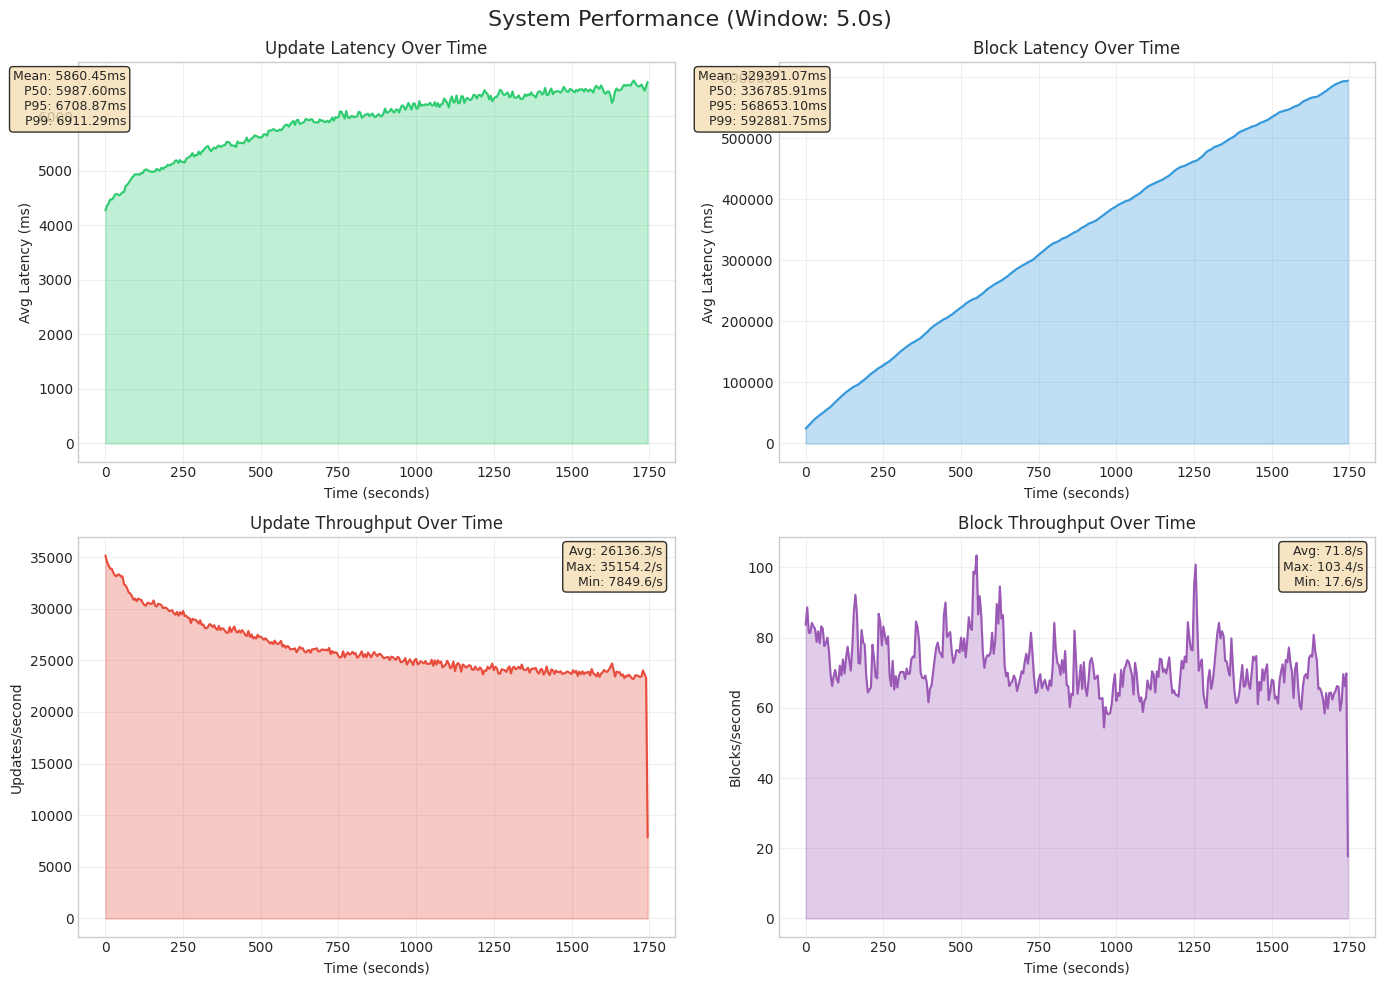

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Update Latency
plot_latency(
    axes[0, 0],
    updates_trimmed,
    "Update Latency Over Time",
    "Avg Latency (ms)",
    "#2ecc71",
    WINDOW_S,
)

# Plot 2: Block Latency
plot_latency(
    axes[0, 1],
    blocks_trimmed,
    "Block Latency Over Time",
    "Avg Latency (ms)",
    "#3498db",
    WINDOW_S,
)

# Plot 3: Update Throughput
plot_throughput(
    axes[1, 0],
    updates_trimmed,
    "time_normalized",
    "Update Throughput Over Time",
    "Updates/second",
    "#e74c3c",
    WINDOW_S,
)

# Plot 4: Block Throughput
plot_throughput(
    axes[1, 1],
    blocks_trimmed,
    "time_normalized",
    "Block Throughput Over Time",
    "Blocks/second",
    "#9b59b6",
    WINDOW_S,
)

plt.suptitle(f"System Performance (Window: {WINDOW_S}s)", fontsize=16)
plt.tight_layout()
plt.show()

## Per-Worker Performance

Detailed breakdown of latency and throughput by worker ID.

Found 32workers: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31)]


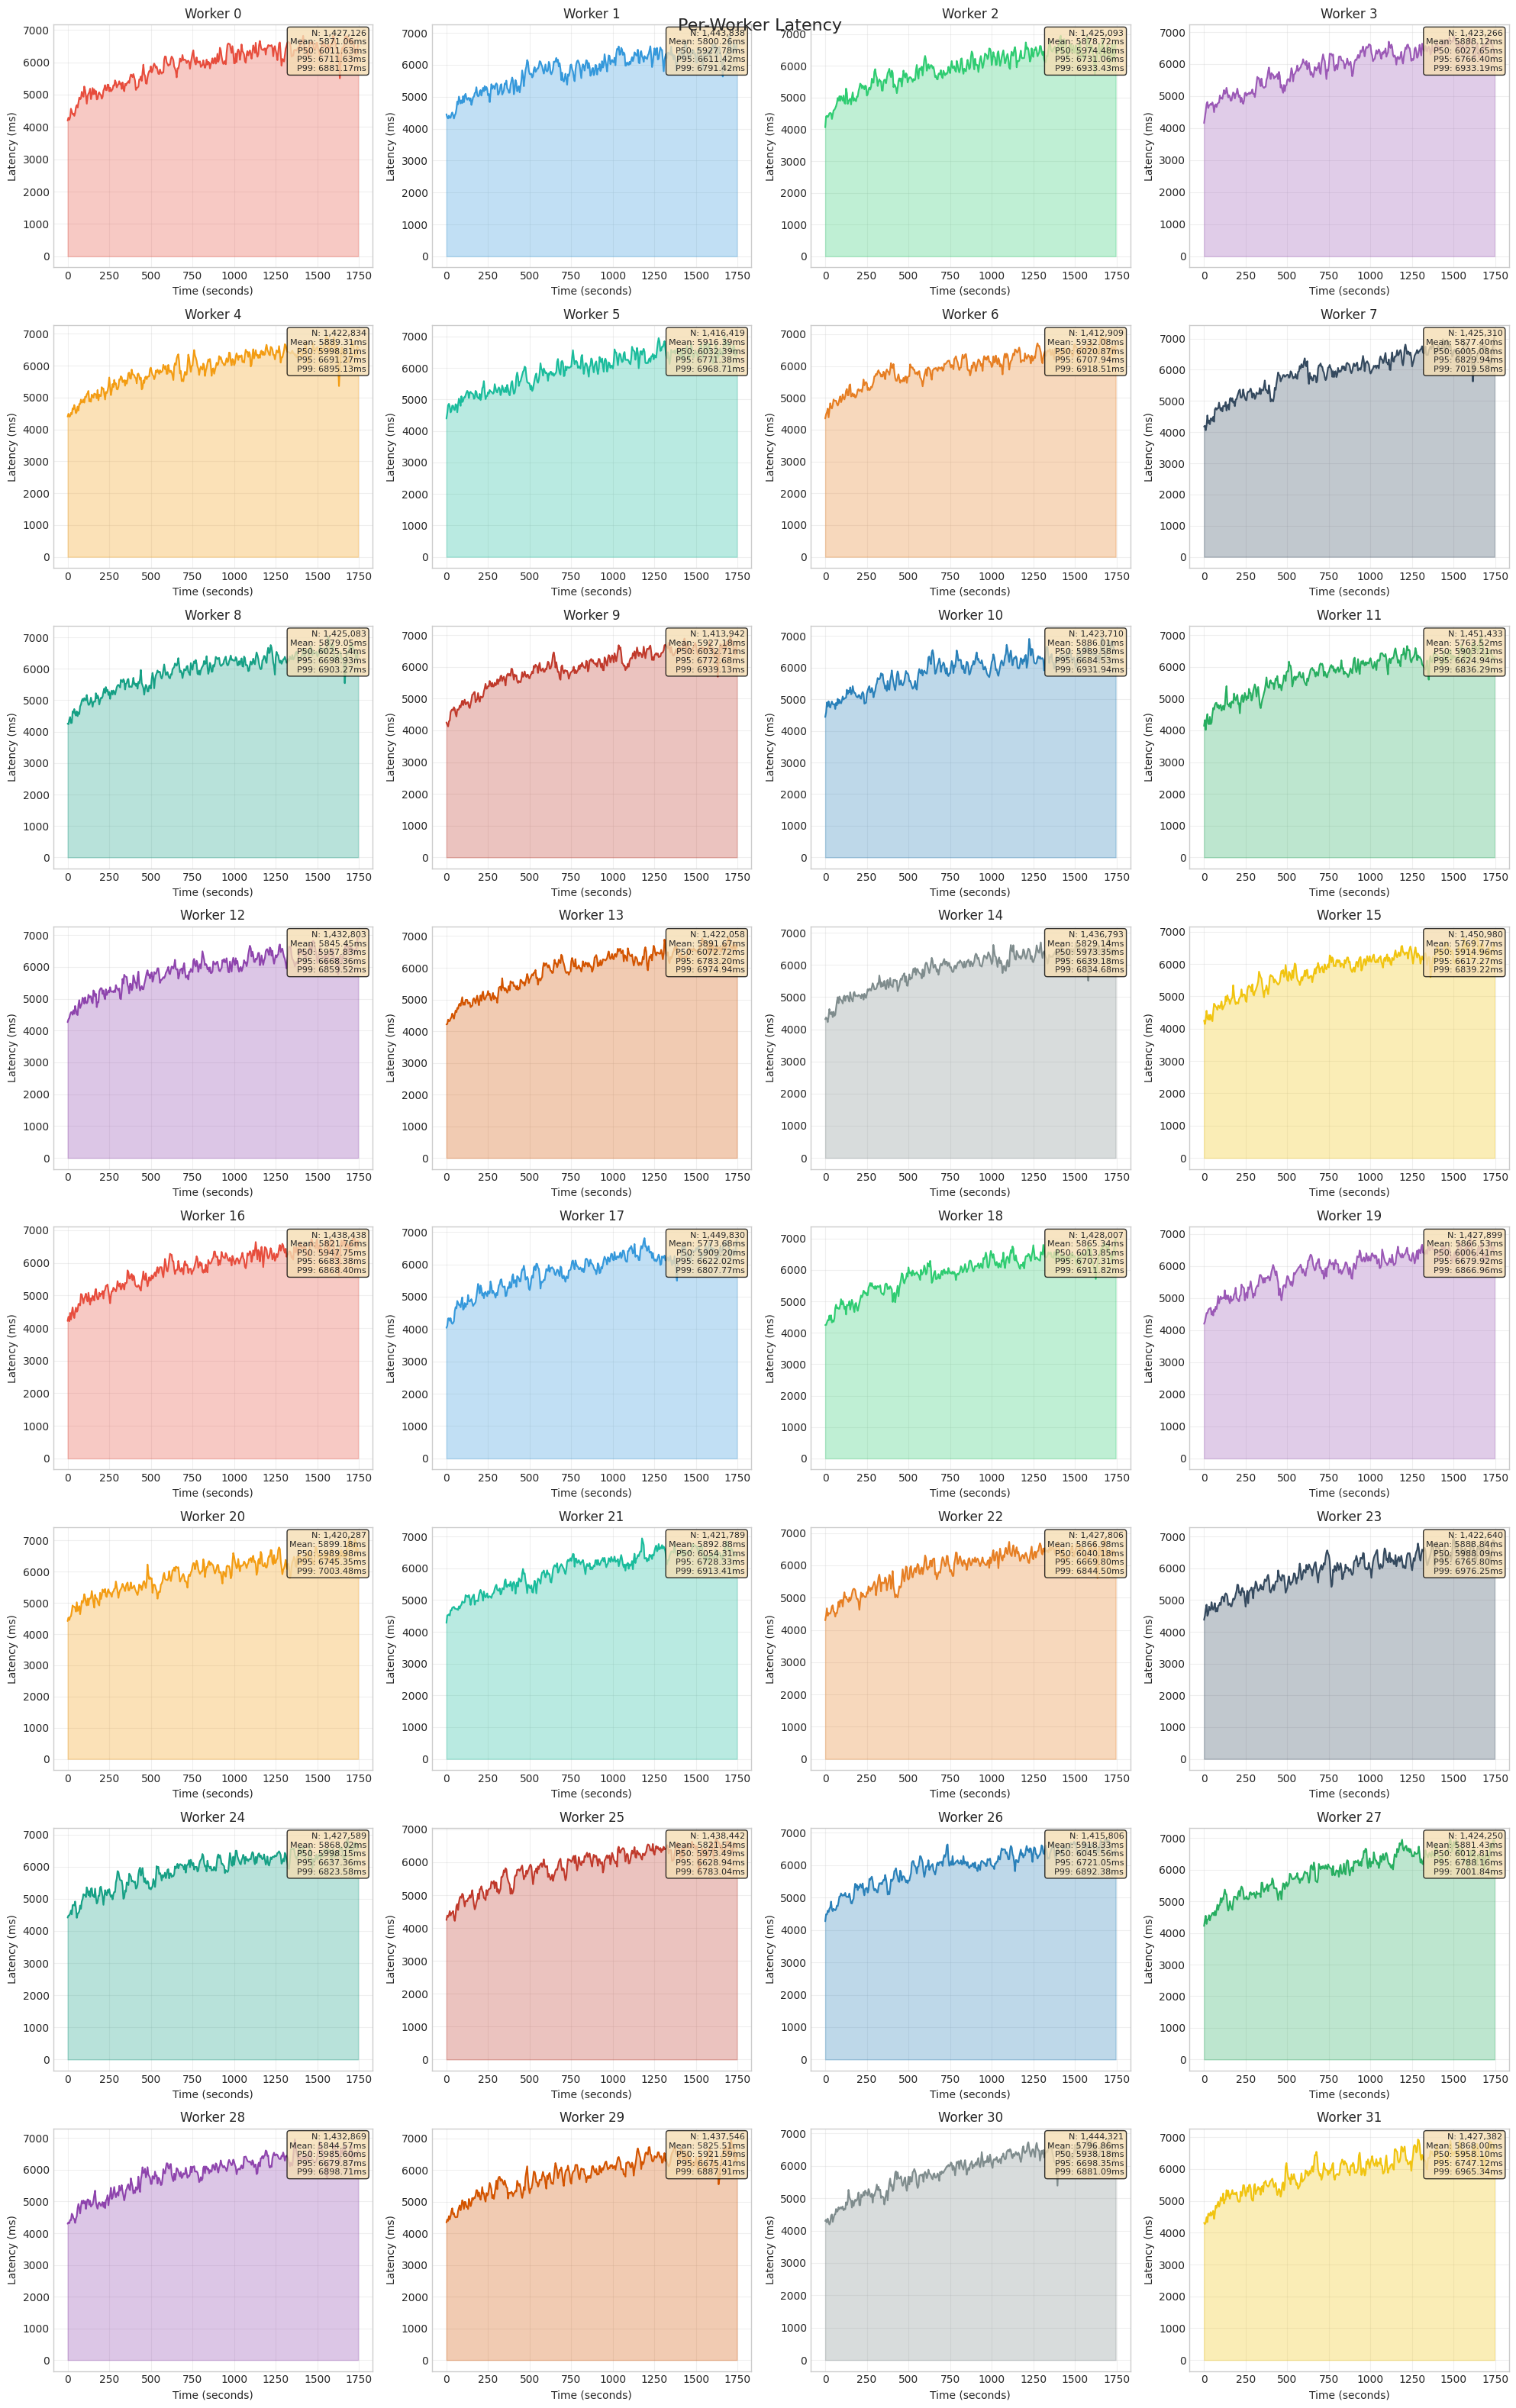

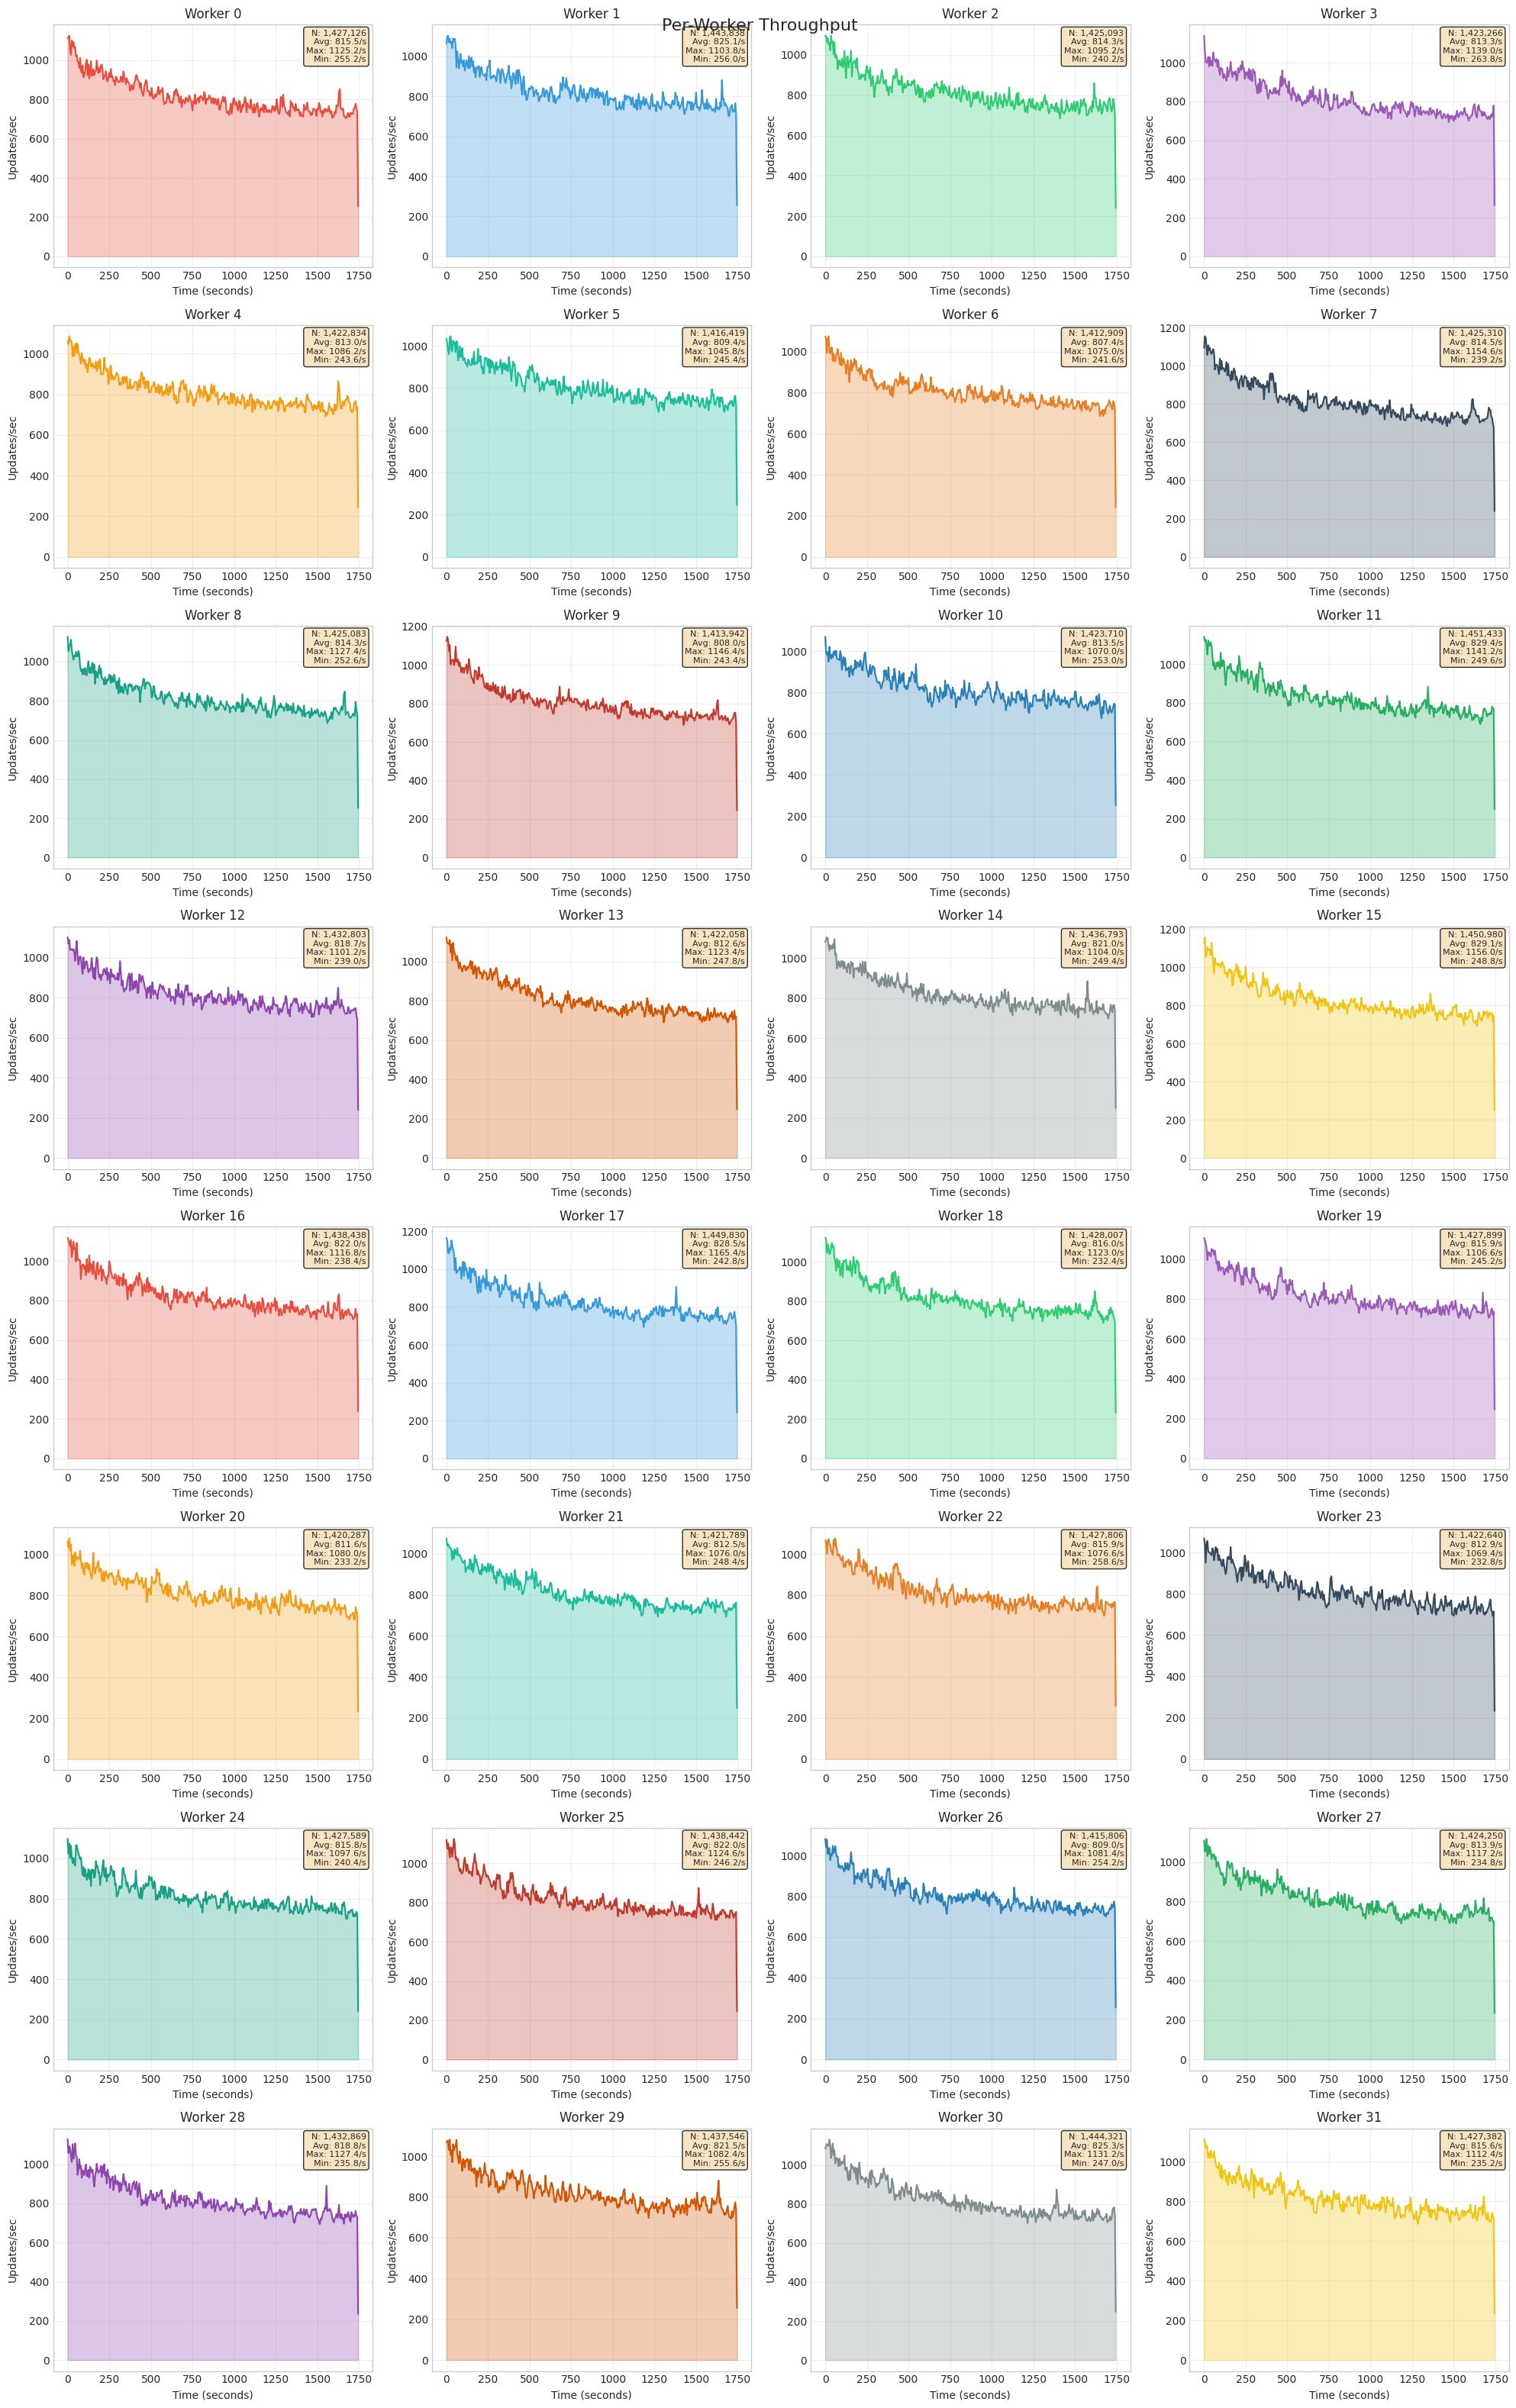

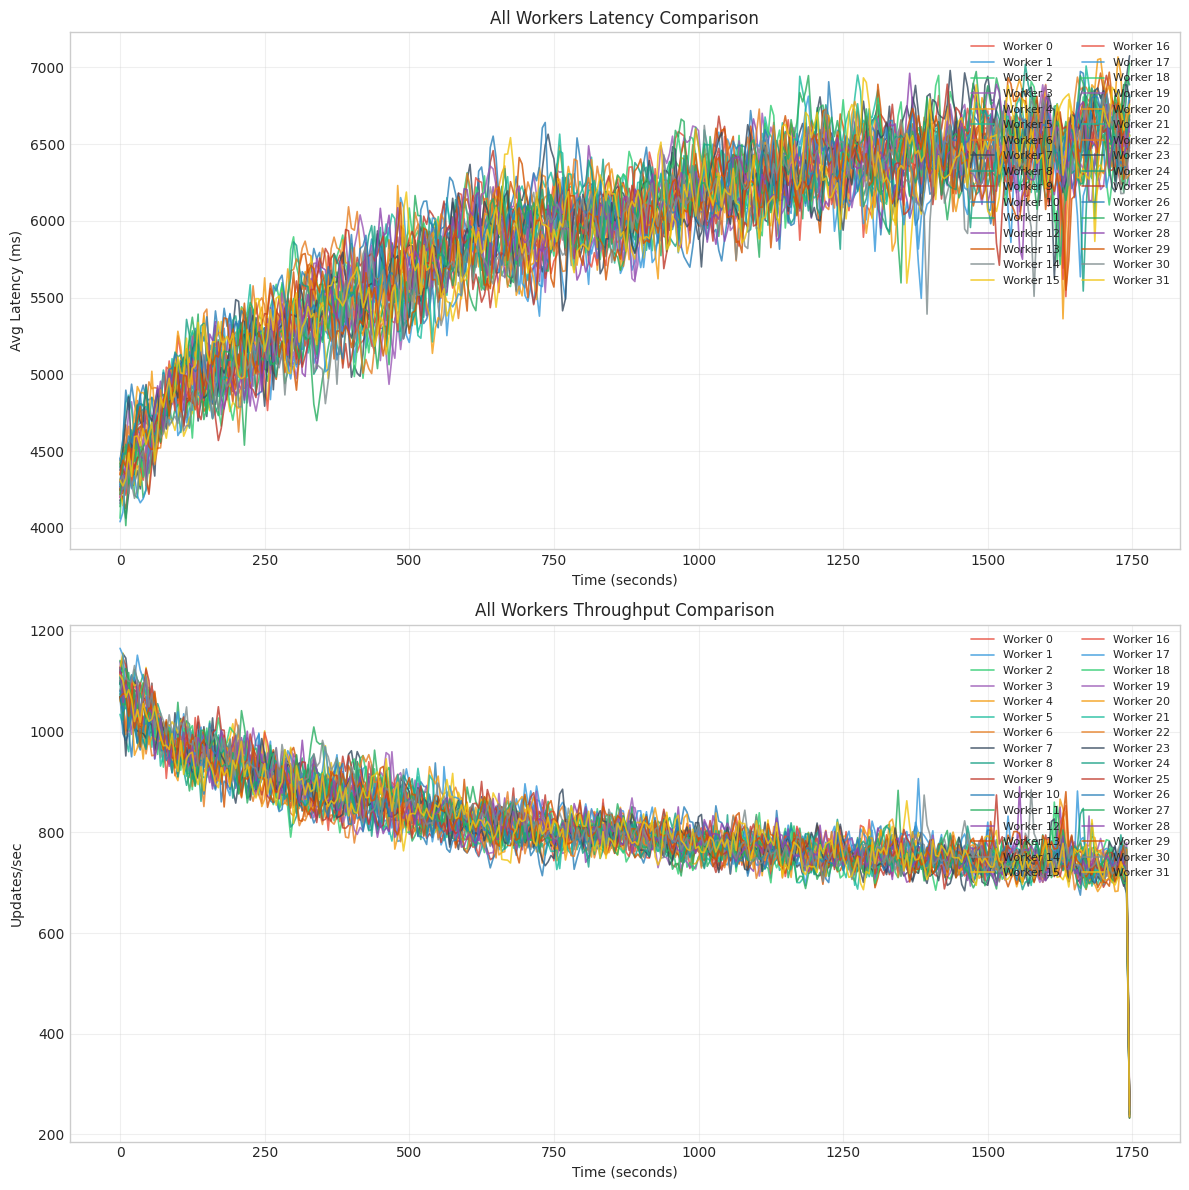

In [8]:
if "worker_id" in updates_trimmed.columns and not updates_trimmed.empty:
    worker_ids = sorted(updates_trimmed["worker_id"].unique())
    num_workers = len(worker_ids)
    
    print(f"Found {num_workers}workers: {worker_ids}")
    
    # Color palette
    colors = [
        "#e74c3c", "#3498db", "#2ecc71", "#9b59b6", "#f39c12",
        "#1abc9c", "#e67e22", "#34495e", "#16a085", "#c0392b",
        "#2980b9", "#27ae60", "#8e44ad", "#d35400", "#7f8c8d",
        "#f1c40f",
    ]
    
    # Determine grid layout
    cols = min(4, num_workers)
    rows = (num_workers + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    if num_workers == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
        
    for i, worker_id in enumerate(worker_ids):
        worker_df = updates_trimmed[updates_trimmed["worker_id"] == worker_id]
        plot_worker_latency(
            axes[i],
            worker_df,
            worker_id,
            colors[i % len(colors)],
            WINDOW_S,
        )
        
    # Hide unused subplots
    for i in range(num_workers, len(axes)):
        axes[i].set_visible(False)
        
    plt.suptitle("Per-Worker Latency", fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Throughput plots
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    if num_workers == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
        
    for i, worker_id in enumerate(worker_ids):
        worker_df = updates_trimmed[updates_trimmed["worker_id"] == worker_id]
        plot_worker_throughput(
            axes[i],
            worker_df,
            worker_id,
            colors[i % len(colors)],
            WINDOW_S,
        )
        
    for i in range(num_workers, len(axes)):
        axes[i].set_visible(False)
        
    plt.suptitle("Per-Worker Throughput", fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Overlays
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))
    
    plot_all_workers_latency_overlay(ax1, updates_trimmed, colors, WINDOW_S)
    plot_all_workers_throughput_overlay(ax2, updates_trimmed, colors, WINDOW_S)
    
    plt.tight_layout()
    plt.show()

else:
    print("Worker data unavailable or empty.")

## Summary Statistics

In [9]:
if "worker_id" in updates_trimmed.columns and not updates_trimmed.empty:
    total_duration = updates_trimmed["time_normalized"].max() if len(updates_trimmed) > 0 else 1

    print("=" * 90)
    print("Per-Worker Summary Statistics")
    print("=" * 90)
    print(f"{'Worker':<8} {'Count':>10} {'Avg Throughput':>16} {'Mean(ms)':>12} {'P50(ms)':>10} {'P95(ms)':>10} {'P99(ms)':>10}")
    print("-" * 90)
    for worker_id in worker_ids:
        worker_df = updates_trimmed[updates_trimmed["worker_id"] == worker_id]
        if len(worker_df) > 0:
            count = len(worker_df)
            throughput = count / total_duration if total_duration > 0 else 0
            mean = worker_df["latency_ms"].mean()
            p50 = worker_df["latency_ms"].median()
            p95 = worker_df["latency_ms"].quantile(0.95)
            p99 = worker_df["latency_ms"].quantile(0.99)
            print(f"{worker_id:<8} {count:>10,} {throughput:>14.1f}/s {mean:>12.2f} {p50:>10.2f} {p95:>10.2f} {p99:>10.2f}")
    print("=" * 90)

Per-Worker Summary Statistics
Worker        Count   Avg Throughput     Mean(ms)    P50(ms)    P95(ms)    P99(ms)
------------------------------------------------------------------------------------------
0         1,427,126          817.0/s      5871.06    6011.63    6711.63    6881.17


1         1,443,838          826.6/s      5800.26    5927.78    6611.42    6791.42
2         1,425,093          815.9/s      5878.72    5974.48    6731.06    6933.43
3         1,423,266          814.8/s      5888.12    6027.65    6766.40    6933.19
4         1,422,834          814.6/s      5889.31    5998.81    6691.27    6895.13
5         1,416,419          810.9/s      5916.39    6032.39    6771.38    6968.71
6         1,412,909          808.9/s      5932.08    6020.87    6707.94    6918.51
7         1,425,310          816.0/s      5877.40    6005.08    6829.94    7019.58
8         1,425,083          815.9/s      5879.05    6025.54    6698.93    6903.27
9         1,413,942          809.5/s      5927.18    6032.71    6772.68    6939.13
10        1,423,710          815.1/s      5886.01    5989.58    6684.53    6931.94
11        1,451,433          831.0/s      5763.52    5903.21    6624.94    6836.29
12        1,432,803          820.3/s      5845.45    5957.83    6668.36    6859.52
13  